In [20]:
import getpass
import os
def _set_env(key: str):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"{key}")

_set_env("OPENAI_API_KEY")

In [23]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

docs = [WebBaseLoader(url).load() for url in urls]
doc_list = [item for sublist in docs for item in sublist]

text_splitter=RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100, chunk_overlap=0)

doc_splits=text_splitter.split_documents(doc_list)

vector_store=Chroma.from_documents(
    documents=doc_splits, collection_name="rag-chroma", embedding=OpenAIEmbeddings()
)
retriever = vector_store.as_retriever()

In [24]:
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool=create_retriever_tool(retriever, "retrieve_blog_posts",
                     "search and retrun information about lilian weng blog posts on LLM agents, prompt engineering, and adversarial attacks on LLMs ")
tools = [retriever_tool]

In [25]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [82]:
from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

from langgraph.prebuilt import tools_condition


def grade_documents(state):
    print("----check relevance------")

    class grade(BaseModel):
        binary_score: str = Field(description="relevance score of yes or no")

    model = ChatOpenAI(model="gpt-4", temperature=0, streaming=True)
    llm_with_tool = model.with_structured_output(grade)

    prompt = PromptTemplate(
        template = """ you are a grader assessing relelvance of a retrieved documents to a user question.
        Here is the retrieved document: \n \n {context} \n\n
        here is the user question:: {question}
        if the document contains keyword's or semantic meaning related to the user question, grade it as a relevant. \n
        give a binar score 'yes' or 'no' score to indicate whether the document is relevant to the question.
        """,
        input_variables=["context", "question"]
    )

    chain = prompt | llm_with_tool
    message = state["messages"]
    print("----------messages-----------", message)
    last_message = message[-1]
    question = message[0].content
    docs=last_message.content

    scored_result=chain.invoke({"question": question, "context": docs})
    score=scored_result.binary_score
    if score=="yes":
        print("------decision docs relevant--------")
        return "generate"
    if score=="no":
        print("------decision docs not relevant")
        return "rewrite"


def agent(state):
    print("--------call agent--------")
    messages=state["messages"]
    print({"messages": messages })
    model=ChatOpenAI(temperature=0, streaming=True, model="gpt-4")
    model=model.bind_tools(tools)
    response=model.invoke(messages)
    print({"response": [response]})
    return {"messages":[response]}

def rewrite(state):
    print("---------transform query-------")
    messages=state["messages"]
    question=message[0].content

    msg = [
        HumanMessage(
            content=f"""\n
            look at the input and tru to reason about the underlying semantic intent / meaning
            .\n here is the initial question
            {question}
            \n-----------\n
            formulate an improved question"""
        )
    ]
    model=ChatOpenAI(temperature=0, model="gpt-4", streaming=True)
    response = model.invoke(msg)
    return {"messages": [response]}


def generate(state):
    print("-----generate-----")
    messages=state["messages"]
    question=messages[0].content
    last_message=messages[-1]
    docs =  last_message.content

    prompt = hub.pull('rlm/rag-prompt')

    llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0, streaming=True)

    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

print("*" * 20 + "Prompt[rlm/rag-prompt]" + "*" * 20)
prompt = hub.pull("rlm/rag-prompt").pretty_print() 

********************Prompt[rlm/rag-prompt]********************
================================ Human Message =================================

You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.
Question: {question} 
Context: {context} 
Answer:


In [83]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)
retrieve=ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)
workflow.add_node("rewrite", rewrite)
workflow.add_node("generate", generate)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", tools_condition,
                              {
                                  "tools":"retrieve",
                                  END: END
                              })

workflow.add_conditional_edges(
    "retrieve", grade_documents
)

workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

graph = workflow.compile()

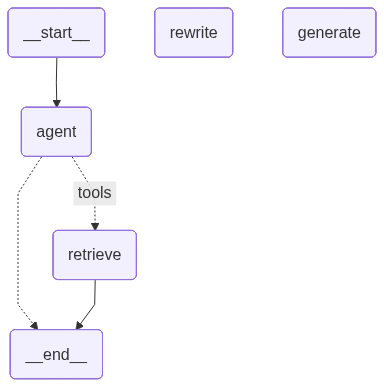

In [84]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [89]:
import pprint

inputs = {
    "messages":[
        ("user", "how the lilang agents works?")
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"output from node '{key}':")
        pprint.pprint("----------")
        pprint.pprint(value, indent=2, width=80, depth=None)

    pprint.pprint("\n----------\n")

--------call agent--------
{'messages': [HumanMessage(content='how the lilang agents works?', additional_kwargs={}, response_metadata={}, id='25436b22-f008-4852-830b-c4621480b1b9')]}
{'response': [AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4-0613', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--019d0bb2-98e1-7b13-82f7-799a92741baf', tool_calls=[{'name': 'retrieve_blog_posts', 'args': {'query': 'lilian weng blog post on LLM agents'}, 'id': 'call_2IKOpQ1Ulaccn0byoarIzd54', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 85, 'output_tokens': 25, 'total_tokens': 110, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}
"output from node 'agent':"
'----------'
{ 'messages': [ AIMessage(content='', additional_kwargs={}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4-0613', 'service_tier': 'de

D:\Download_New\anaconda\envs\ai_env\Lib\site-packages\langchain_openai\chat_models\base.py:2214: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


------decision docs relevant--------
"output from node 'retrieve':"
'----------'
{ 'messages': [ ToolMessage(content='Weng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\n\nCitation#\nCited as:\n\nWeng, Lilian. (Oct 2023). “Adversarial Attacks on LLMs”. Lil’Log. https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/.\n\nCitation#\nCited as:\n\nWeng, Lilian. (Oct 2023). “Adversarial Attacks on LLMs”. Lil’Log. https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/.', name='retrieve_blog_posts', id='091c7448-2a6f-4993-a5e4-a9d856648362', tool_call_id='call_2IKOpQ1Ulaccn0byoarIzd54')]}
'\n----------\n'
-----generate-----
"output from node 'generate':"
'----------'
{ 'messages': [ 'The Lilang agents work by being powered by LLM (Large '
                'Language Models) to operate auto